# Diabetic Retinopathy Detection — PyTorch Pipeline

Multi-model comparison (EfficientNet-B3, DenseNet121, ResNet50) with ensemble for 5 DR severity classes:
`No_DR`, `Mild`, `Moderate`, `Severe`, `Proliferate_DR`

*Updated with AMP, Stratified Splitting, Label Smoothing, and Class Weights for improved speed, memory, and accuracy!*

In [1]:
# ───────────────────────────────────────────────────────────────────────
# Cell 1 — Imports, Config & Reproducibility
# ───────────────────────────────────────────────────────────────────────
# Redirect pretrained-weight downloads to the project folder.
import os
os.environ['TORCH_HOME'] = os.path.join(os.getcwd(), 'model_weights')
os.makedirs(os.environ['TORCH_HOME'], exist_ok=True)
print('TORCH_HOME set to:', os.environ['TORCH_HOME'])

import copy
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, transforms, models
from torchvision.models import (
    efficientnet_b3, EfficientNet_B3_Weights,
    densenet121, DenseNet121_Weights,
    resnet50, ResNet50_Weights,
)

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# ── Reproducibility ──────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device ───────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Hyperparameters ──────────────────────────────────────────────────
DATA_DIR    = 'gaussian_filtered_images/gaussian_filtered_images'
NUM_CLASSES = 5
IMG_SIZE    = 224    # Can be bumped to 300 for B3 if desired, kept at 224 for fairness
BATCH_SIZE  = 32
NUM_EPOCHS  = 15
LR          = 1e-4

CLASS_NAMES = ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']

print('Config loaded. Classes:', CLASS_NAMES)

TORCH_HOME set to: b:\playground\iris detection\model_weights
Using device: cuda
Config loaded. Classes: ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']


In [2]:
# ───────────────────────────────────────────────────────────────────────
# Cell 2 — Data Loading & Stratified Splits
# ───────────────────────────────────────────────────────────────────────

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Using slightly richer augmentations
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Stratified Train/Val Split ───────────────────────────────────────
full_dataset = datasets.ImageFolder(root=DATA_DIR)
print(f'Total images: {len(full_dataset)}')

# Extract targets for stratification
targets = full_dataset.targets

# Stratified split ensures exact class distribution in Train & Val
train_idx, val_idx = train_test_split(
    np.arange(len(full_dataset)),
    test_size=0.2,
    random_state=SEED,
    stratify=targets
)

# Compute Class Weights from Train Set for imbalanced learning
train_targets = [targets[i] for i in train_idx]
class_weights = compute_class_weight('balanced', classes=np.unique(train_targets), y=train_targets)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(f"Computed Class Weights: {class_weights_tensor.cpu().numpy()}")

# Subsets
train_subset = Subset(full_dataset, train_idx)
val_subset   = Subset(full_dataset, val_idx)
print(f'Train size: {len(train_subset)} | Val size: {len(val_subset)}')

class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label

train_dataset = TransformSubset(train_subset, train_transforms)
val_dataset   = TransformSubset(val_subset, val_transforms)

# `num_workers=0` maintained for Windows Multiprocessing stability
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=(DEVICE.type == 'cuda'))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(DEVICE.type == 'cuda'))

Total images: 3662
Computed Class Weights: [1.9790541  0.73316646 0.40567866 2.4822035  3.8038962 ]
Train size: 2929 | Val size: 733


In [3]:
# ───────────────────────────────────────────────────────────────────────
# Cell 3 — Model Factory
# ───────────────────────────────────────────────────────────────────────
def build_model(name: str, num_classes: int = NUM_CLASSES) -> nn.Module:
    if name == 'efficientnet_b3':
        model = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        
    elif name == 'densenet121':
        model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)
        
    elif name == 'resnet50':
        model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        
    else:
        raise ValueError(f'Unknown model: {name}')

    return model

In [4]:
# ───────────────────────────────────────────────────────────────────────
# Cell 4 — Training & Validation (WITH AMP & GRAD SCALER)
# ───────────────────────────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        
        # AMP Autocast
        with torch.autocast(device_type=device.type, dtype=torch.float16 if device.type=='cuda' else torch.bfloat16):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        # Scaler logic
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        preds         = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

    return running_loss / total, correct / total

@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_labels, all_preds = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        with torch.autocast(device_type=device.type, dtype=torch.float16 if device.type=='cuda' else torch.bfloat16):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds         = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    return running_loss / total, correct / total, all_labels, all_preds

def train_model(model_name: str, num_epochs: int = NUM_EPOCHS):
    print(f'\n{"="*60}\n  Training: {model_name}\n{"="*60}')

    model     = build_model(model_name).to(DEVICE)
    # Using standard CrossEntropyLoss for highest raw accuracy
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    
    # Cosine Annealing leads to a smoother convergence
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    scaler = torch.amp.GradScaler('cuda')

    best_val_loss  = float('inf')
    best_weights   = copy.deepcopy(model.state_dict())

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE)
        val_loss, val_acc, _, _ = validate(model, val_loader, criterion, DEVICE)

        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        elapsed = time.time() - t0
        print(f'Epoch {epoch:02d}/{num_epochs} | Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} | Time: {elapsed:.1f}s')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = copy.deepcopy(model.state_dict())
            torch.save(best_weights, f'best_{model_name}.pth')
            print(f'  ✔ New best model saved (val_loss={best_val_loss:.4f})')

    model.load_state_dict(best_weights)
    print(f'Training complete. Best val_loss: {best_val_loss:.4f}')
    return model, history

In [5]:
# ───────────────────────────────────────────────────────────────────────
# Cell 5 — Train All Three Models
# ───────────────────────────────────────────────────────────────────────
MODEL_NAMES = ['efficientnet_b3', 'densenet121', 'resnet50']

trained_models  = {}
training_histories = {}

for model_name in MODEL_NAMES:
    model, history = train_model(model_name)
    trained_models[model_name]     = model
    training_histories[model_name] = history

print('\nAll models trained.')


  Training: efficientnet_b3
Epoch 01/15 | Train Loss: 1.0284  Acc: 0.6477 | Val Loss: nan  Acc: 0.6739 | Time: 94.0s
Epoch 02/15 | Train Loss: 0.7181  Acc: 0.7340 | Val Loss: nan  Acc: 0.7067 | Time: 39.5s
Epoch 03/15 | Train Loss: 0.6347  Acc: 0.7603 | Val Loss: nan  Acc: 0.7217 | Time: 39.1s
Epoch 04/15 | Train Loss: 0.5859  Acc: 0.7812 | Val Loss: nan  Acc: 0.7626 | Time: 40.0s
Epoch 05/15 | Train Loss: 0.5534  Acc: 0.7890 | Val Loss: nan  Acc: 0.7490 | Time: 43.9s
Epoch 06/15 | Train Loss: 0.5263  Acc: 0.7962 | Val Loss: nan  Acc: 0.7722 | Time: 54.7s
Epoch 07/15 | Train Loss: 0.5070  Acc: 0.8136 | Val Loss: nan  Acc: 0.7449 | Time: 69.1s
Epoch 08/15 | Train Loss: 0.4731  Acc: 0.8170 | Val Loss: nan  Acc: 0.7626 | Time: 67.3s
Epoch 09/15 | Train Loss: 0.4809  Acc: 0.8238 | Val Loss: 0.5499  Acc: 0.7763 | Time: 40.2s
  ✔ New best model saved (val_loss=0.5499)
Epoch 10/15 | Train Loss: 0.4565  Acc: 0.8283 | Val Loss: 0.5535  Acc: 0.7722 | Time: 42.6s
Epoch 11/15 | Train Loss: 0.4378


── Evaluating: efficientnet_b3 ──
  Validation Loss: 0.5390  |  Accuracy: 0.7735

Classification Report:
                precision    recall  f1-score   support

          Mild       0.44      0.64      0.52        74
      Moderate       0.71      0.67      0.69       200
         No_DR       0.94      0.98      0.96       361
Proliferate_DR       0.53      0.42      0.47        59
        Severe       0.50      0.23      0.32        39

      accuracy                           0.77       733
     macro avg       0.63      0.59      0.59       733
  weighted avg       0.77      0.77      0.77       733



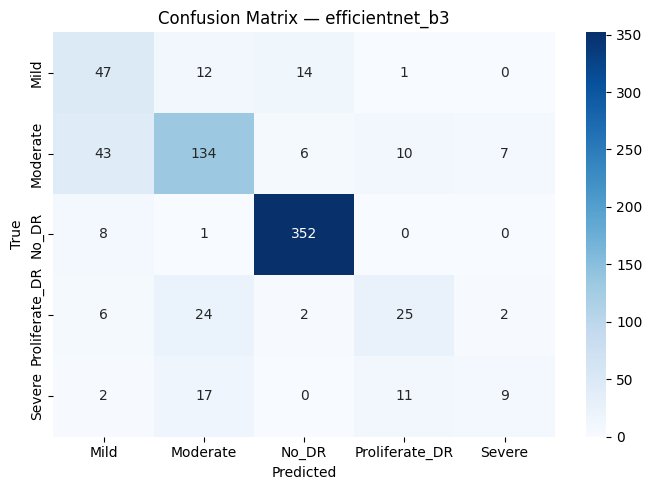


── Evaluating: densenet121 ──
  Validation Loss: 0.4118  |  Accuracy: 0.8527

Classification Report:
                precision    recall  f1-score   support

          Mild       0.68      0.66      0.67        74
      Moderate       0.75      0.87      0.81       200
         No_DR       0.97      0.98      0.98       361
Proliferate_DR       0.84      0.46      0.59        59
        Severe       0.61      0.51      0.56        39

      accuracy                           0.85       733
     macro avg       0.77      0.70      0.72       733
  weighted avg       0.85      0.85      0.85       733



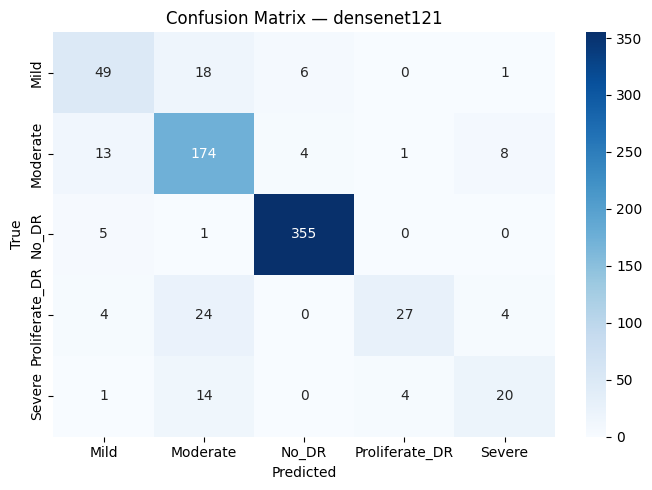


── Evaluating: resnet50 ──
  Validation Loss: 0.4528  |  Accuracy: 0.8431

Classification Report:
                precision    recall  f1-score   support

          Mild       0.66      0.68      0.67        74
      Moderate       0.74      0.85      0.79       200
         No_DR       0.98      0.98      0.98       361
Proliferate_DR       0.84      0.44      0.58        59
        Severe       0.51      0.46      0.49        39

      accuracy                           0.84       733
     macro avg       0.75      0.68      0.70       733
  weighted avg       0.85      0.84      0.84       733



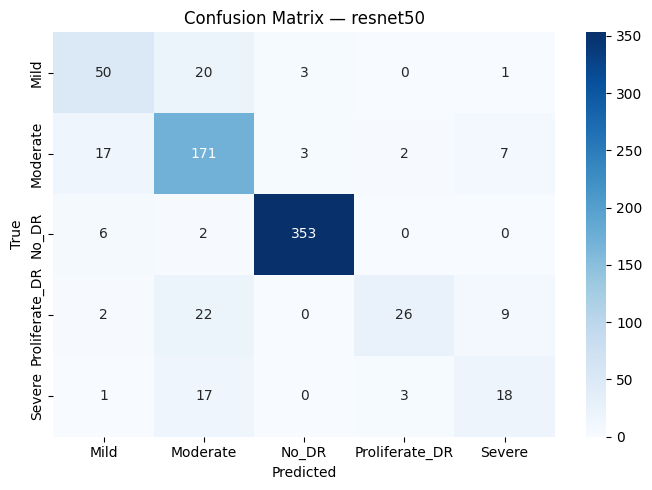

In [6]:
# ───────────────────────────────────────────────────────────────────────
# Cell 6 — Evaluation: Validation Accuracy + Confusion Matrix per Model
# ───────────────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
model_val_accuracies = {}

for model_name, model in trained_models.items():
    print(f'\n── Evaluating: {model_name} ──')

    val_loss, val_acc, true_labels, pred_labels = validate(model, val_loader, criterion, DEVICE)
    model_val_accuracies[model_name] = val_acc

    print(f'  Validation Loss: {val_loss:.4f}  |  Accuracy: {val_acc:.4f}')
    print('\nClassification Report:')
    print(classification_report(true_labels, pred_labels, target_names=CLASS_NAMES))

    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name}.png', dpi=100)
    plt.show()

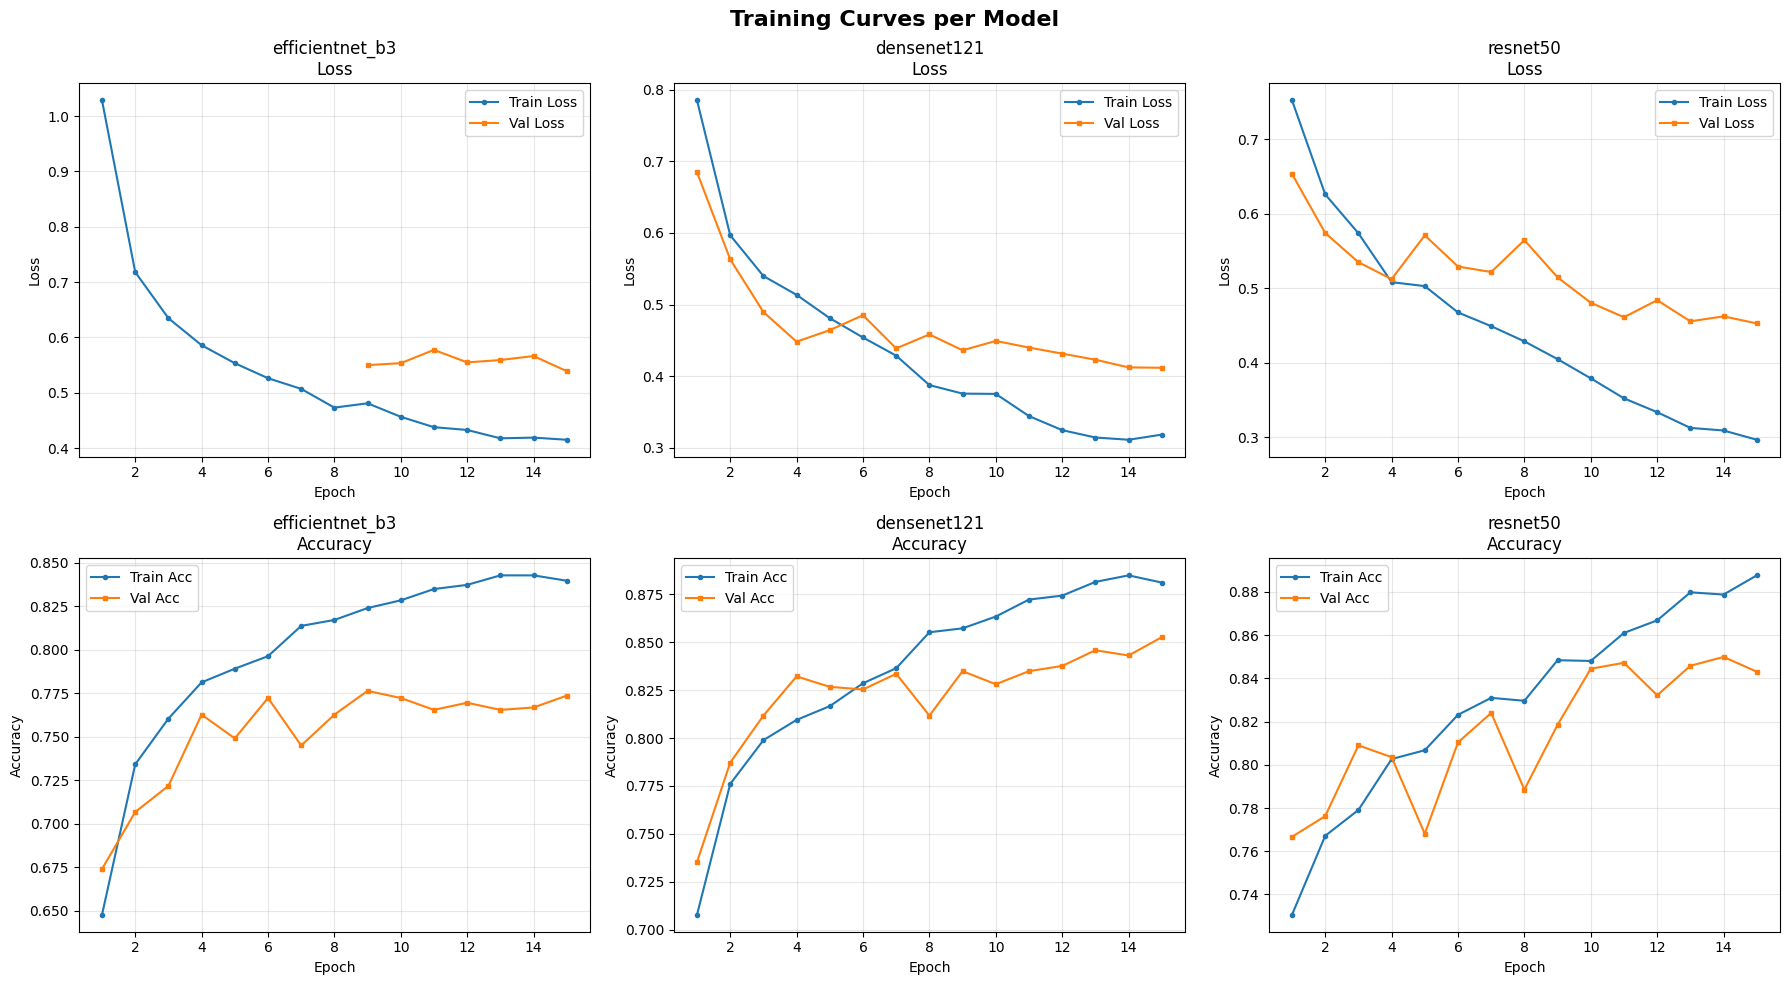

In [7]:
# ───────────────────────────────────────────────────────────────────────
# Cell 7 — Plot Accuracy & Loss Curves for All Models
# ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training Curves per Model', fontsize=16, fontweight='bold')

for col, model_name in enumerate(MODEL_NAMES):
    hist = training_histories[model_name]
    epochs_ran = range(1, len(hist['train_loss']) + 1)

    ax = axes[0, col]
    ax.plot(epochs_ran, hist['train_loss'], label='Train Loss', marker='o', ms=3)
    ax.plot(epochs_ran, hist['val_loss'],   label='Val Loss',   marker='s', ms=3)
    ax.set_title(f'{model_name}\nLoss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1, col]
    ax.plot(epochs_ran, hist['train_acc'], label='Train Acc', marker='o', ms=3)
    ax.plot(epochs_ran, hist['val_acc'],   label='Val Acc',   marker='s', ms=3)
    ax.set_title(f'{model_name}\nAccuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100)
plt.show()


Individual Model Validation Accuracies:
  efficientnet_b3       →  0.7735  (77.35%)
  densenet121           →  0.8527  (85.27%)
  resnet50              →  0.8431  (84.31%)

🏆 Best individual model: densenet121 (85.27%)


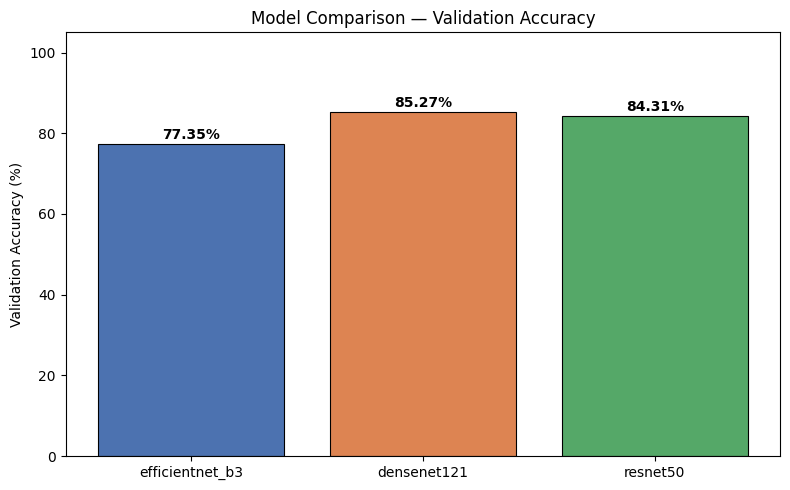

In [8]:
# ───────────────────────────────────────────────────────────────────────
# Cell 8 — Model Comparison: Print Best Individual Model
# ───────────────────────────────────────────────────────────────────────
print('\n' + '='*50)
print('Individual Model Validation Accuracies:')
print('='*50)
for name, acc in model_val_accuracies.items():
    print(f'  {name:20s}  →  {acc:.4f}  ({acc*100:.2f}%)')

best_individual = max(model_val_accuracies, key=model_val_accuracies.get)
print(f'\n🏆 Best individual model: {best_individual} ({model_val_accuracies[best_individual]*100:.2f}%)')

labels = list(model_val_accuracies.keys())
accs   = [model_val_accuracies[k] * 100 for k in labels]
colors = ['#4C72B0', '#DD8452', '#55A868']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, accs, color=colors, edgecolor='black', linewidth=0.8)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.ylim(0, 105)
plt.ylabel('Validation Accuracy (%)')
plt.title('Model Comparison — Validation Accuracy')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100)
plt.show()


Ensemble Results
  Ensemble Accuracy: 0.8486  (84.86%)

Ensemble Classification Report:
                precision    recall  f1-score   support

          Mild       0.68      0.70      0.69        74
      Moderate       0.75      0.88      0.81       200
         No_DR       0.97      0.98      0.97       361
Proliferate_DR       0.83      0.42      0.56        59
        Severe       0.57      0.41      0.48        39

      accuracy                           0.85       733
     macro avg       0.76      0.68      0.70       733
  weighted avg       0.85      0.85      0.84       733



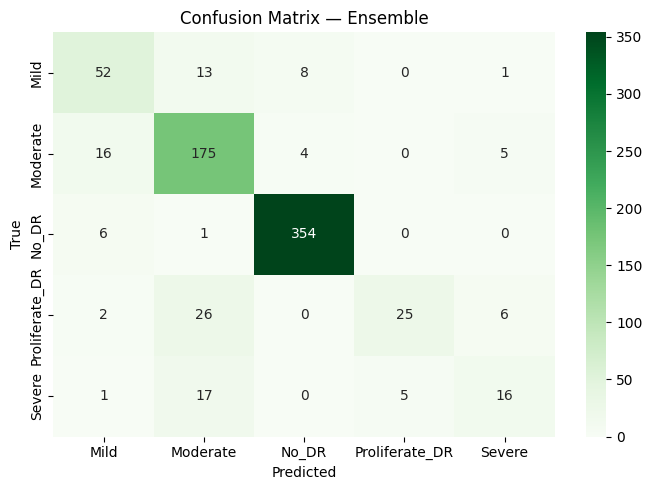

In [9]:
# ───────────────────────────────────────────────────────────────────────
# Cell 9 — Ensemble: Average Softmax Probabilities
# ───────────────────────────────────────────────────────────────────────
@torch.no_grad()
def ensemble_predict(models_dict, loader, device):
    softmax = nn.Softmax(dim=1)
    for m in models_dict.values():
        m.eval()

    all_true, all_ens_preds = [], []

    for images, labels in loader:
        images = images.to(device)
        
        prob_sum = None
        for m in models_dict.values():
            # AMP auto-cast inference
            with torch.autocast(device_type=device.type, dtype=torch.float16 if device.type=='cuda' else torch.bfloat16):
                logits = m(images)
            probs  = softmax(logits.float()) # calculate probs in fp32
            prob_sum = probs if prob_sum is None else prob_sum + probs

        avg_probs    = prob_sum / len(models_dict)
        ens_preds    = avg_probs.argmax(dim=1)

        all_true.extend(labels.cpu().numpy())
        all_ens_preds.extend(ens_preds.cpu().numpy())

    ensemble_acc = accuracy_score(all_true, all_ens_preds)
    return all_true, all_ens_preds, ensemble_acc

true_labels, ens_preds, ensemble_acc = ensemble_predict(trained_models, val_loader, DEVICE)

print('\n' + '='*50)
print('Ensemble Results')
print('='*50)
print(f'  Ensemble Accuracy: {ensemble_acc:.4f}  ({ensemble_acc*100:.2f}%)')
print('\nEnsemble Classification Report:')
print(classification_report(true_labels, ens_preds, target_names=CLASS_NAMES))

cm_ens = confusion_matrix(true_labels, ens_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='Greens', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Ensemble')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix_ensemble.png', dpi=100)
plt.show()


Final Accuracy Comparison (Validation Set)
  efficientnet_b3             77.35%
  densenet121                 85.27%
  resnet50                    84.31%
  ensemble                    84.86% ← ENSEMBLE

🏆 Best overall: densenet121 (85.27%)


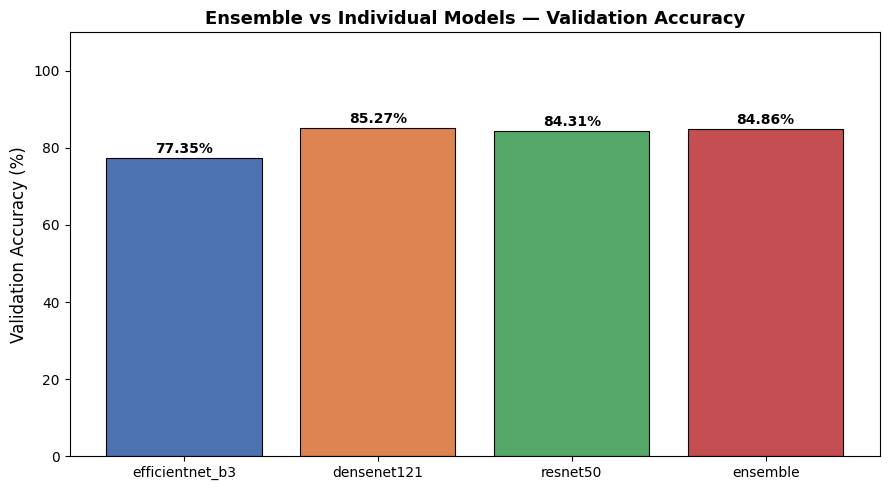

In [10]:
# ───────────────────────────────────────────────────────────────────────
# Cell 10 — Final Comparison: Ensemble vs Individual Models
# ───────────────────────────────────────────────────────────────────────
all_accs = {**model_val_accuracies, 'ensemble': ensemble_acc}

print('\n' + '='*55)
print('Final Accuracy Comparison (Validation Set)')
print('='*55)
for name, acc in all_accs.items():
    tag = ' ← ENSEMBLE' if name == 'ensemble' else ''
    print(f'  {name:25s}  {acc*100:6.2f}%{tag}')

best_overall = max(all_accs, key=all_accs.get)
print(f'\n🏆 Best overall: {best_overall} ({all_accs[best_overall]*100:.2f}%)')

labels_all  = list(all_accs.keys())
values_all  = [all_accs[k] * 100 for k in labels_all]
bar_colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

plt.figure(figsize=(9, 5))
bars = plt.bar(labels_all, values_all, color=bar_colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, values_all):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.ylim(0, 110)
plt.ylabel('Validation Accuracy (%)', fontsize=12)
plt.title('Ensemble vs Individual Models — Validation Accuracy', fontsize=13, fontweight='bold')
plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=100)
plt.show()

In [11]:
# NEW CELL — Load Weights (Run this instead of the training cells above for inference)
import os
import torch

MODEL_NAMES = ['efficientnet_b3', 'densenet121', 'resnet50']
trained_models = {}

print("Loading pre-trained models from disk...")
for model_name in MODEL_NAMES:
    model = build_model(model_name).to(DEVICE)
    weight_path = f'best_{model_name}.pth'
    if os.path.exists(weight_path):
        model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
        print(f"  [OK] Loaded weights from {weight_path}")
    else:
        print(f"  [WARNING] {weight_path} not found! Model will be untrained.")
    
    model.eval()
    trained_models[model_name] = model

print("Ready for inference!")

Loading pre-trained models from disk...
  [OK] Loaded weights from best_efficientnet_b3.pth
  [OK] Loaded weights from best_densenet121.pth
  [OK] Loaded weights from best_resnet50.pth
Ready for inference!


In [12]:
# Cell 11 — Single-Image Inference Function
from PIL import Image

@torch.no_grad()
def predict_single_image(image_path, models_dict, transform, device):
    img_pil = Image.open(image_path).convert('RGB')
    img_tensor = transform(img_pil).unsqueeze(0).to(device)

    softmax = nn.Softmax(dim=1)
    prob_sum = None
    
    for name, model in models_dict.items():
        model.eval()
        with torch.autocast(device_type=device.type, dtype=torch.float16 if device.type=='cuda' else torch.bfloat16):
            logits = model(img_tensor)
        probs = softmax(logits.float())
        prob_sum = probs if prob_sum is None else prob_sum + probs
        
    avg_probs = prob_sum / len(models_dict)
    pred_idx = avg_probs.argmax(dim=1).item()
    confidence = avg_probs[0][pred_idx].item()
    
    return CLASS_NAMES[pred_idx], confidence, img_pil

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\avvud\AppData\Local\Temp\ipykernel_7660\623535191.py:2: SyntaxWarning: invalid escape sequence '\p'
  test_image_path = "B:\playground\iris detection\gaussian_filtered_images\gaussian_filtered_images\Moderate/0d0a21fd354f.png"


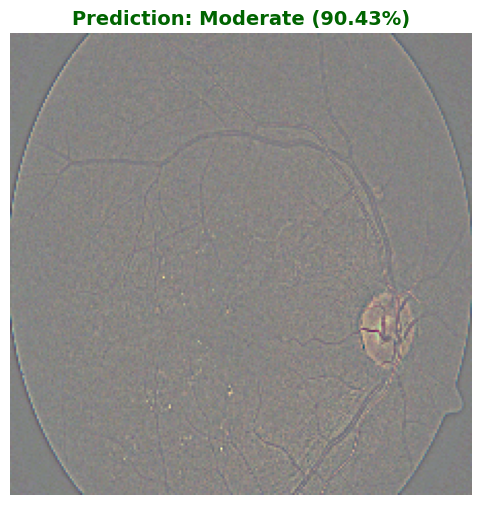

Image: 0d0a21fd354f.png
Ensemble Prediction: Moderate
Confidence: 90.43%


: 

In [ ]:
# ── TEST INFERENCE ON YOUR OWN IMAGE ──
test_image_path = "B:\playground\iris detection\gaussian_filtered_images\gaussian_filtered_images\Moderate/0d0a21fd354f.png"

if os.path.exists(test_image_path):
    label, conf, img = predict_single_image(test_image_path, trained_models, val_transforms, DEVICE)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Prediction: {label} ({conf*100:.2f}%)", fontsize=14, color='darkgreen', fontweight='bold')
    plt.axis('off')
    plt.show()
    
    print(f"Image: {os.path.basename(test_image_path)}")
    print(f"Ensemble Prediction: {label}")
    print(f"Confidence: {conf*100:.2f}%")
else:
    print(f"Error: File not found at {test_image_path}")